In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import requests

In [3]:
url = "https://api.worldbank.org/v2/country/PAK;IND;CHN;GBR/indicator/NY.GDP.PCAP.CD?format=json&per_page=1000"

response = requests.get(url)
data = response.json()

In [4]:
type(data)

list

In [5]:
data[1][:2]


[{'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'CN', 'value': 'China'},
  'countryiso3code': 'CHN',
  'date': '2025',
  'value': 13861.970224368,
  'unit': '',
  'obs_status': '',
  'decimal': 1},
 {'indicator': {'id': 'NY.GDP.PCAP.CD',
   'value': 'GDP per capita (current US$)'},
  'country': {'id': 'CN', 'value': 'China'},
  'countryiso3code': 'CHN',
  'date': '2024',
  'value': 13293.1162269366,
  'unit': '',
  'obs_status': '',
  'decimal': 1}]

In [6]:
df = pd.DataFrame(data[1])

In [7]:
df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2025,13861.970224,,,1
1,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2024,13293.116227,,,1
2,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2023,12951.178240,,,1
3,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2022,12970.605641,,,1
4,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2021,12887.435724,,,1


In [8]:
df = pd.DataFrame(data[1])

In [9]:
df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2025,13861.970224,,,1
1,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2024,13293.116227,,,1
2,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2023,12951.178240,,,1
3,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2022,12970.605641,,,1
4,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'CN', 'value': 'China'}",CHN,2021,12887.435724,,,1


In [10]:
df.columns


Index(['indicator', 'country', 'countryiso3code', 'date', 'value', 'unit',
       'obs_status', 'decimal'],
      dtype='str')

In [11]:
df[['country', 'date', 'value']].head()

,country,date,value
0,"{'id': 'CN', 'value': 'China'}",2025,13861.970224
1,"{'id': 'CN', 'value': 'China'}",2024,13293.116227
2,"{'id': 'CN', 'value': 'China'}",2023,12951.178240
3,"{'id': 'CN', 'value': 'China'}",2022,12970.605641
4,"{'id': 'CN', 'value': 'China'}",2021,12887.435724


In [12]:
df = df[['country', 'date', 'value']]

In [13]:
df.columns = ['Country', 'Year', 'GDP_per_capita']

In [14]:
df.head()

,Country,Year,GDP_per_capita
0,"{'id': 'CN', 'value': 'China'}",2025,13861.970224
1,"{'id': 'CN', 'value': 'China'}",2024,13293.116227
2,"{'id': 'CN', 'value': 'China'}",2023,12951.178240
3,"{'id': 'CN', 'value': 'China'}",2022,12970.605641
4,"{'id': 'CN', 'value': 'China'}",2021,12887.435724


In [15]:
df = pd.DataFrame(data[1])

In [16]:
df['country'] = df['country'].apply(lambda x: x['value'])

In [17]:
df = df[['country', 'date', 'value']]

In [18]:
df.columns = ['Country', 'Year', 'GDP_per_capita']

In [19]:
df.head()

,Country,Year,GDP_per_capita
0,China,2025,13861.970224
1,China,2024,13293.116227
2,China,2023,12951.178240
3,China,2022,12970.605641
4,China,2021,12887.435724


In [20]:
df['Country'].unique()

<StringArray>
['China', 'United Kingdom', 'India', 'Pakistan']
Length: 4, dtype: str

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         264 non-null    str    
 1   Year            264 non-null    str    
 2   GDP_per_capita  264 non-null    float64
dtypes: float64(1), str(2)
memory usage: 6.3 KB


In [22]:
df.isna().sum()

Country           0
Year              0
GDP_per_capita    0
dtype: int64

In [23]:
df.dtypes


Country               str
Year                  str
GDP_per_capita    float64
dtype: object

In [24]:
df['Year'] = pd.to_numeric(df['Year'])
df['GDP_per_capita'] = pd.to_numeric(df['GDP_per_capita'])

In [25]:
df.dtypes

Country               str
Year                int64
GDP_per_capita    float64
dtype: object

In [26]:
df['Country'].value_counts()

Country
China             66
United Kingdom    66
India             66
Pakistan          66
Name: count, dtype: int64

In [27]:
df['Year'].min(), df['Year'].max()

(np.int64(1960), np.int64(2025))

In [28]:
df = df[df['Year'] >= 2000]
df['Year'].max()

np.int64(2025)

In [29]:
df.shape

(104, 3)

In [30]:
df = df.sort_values(['Country', 'Year'])
df.head(10)

,Country,Year,GDP_per_capita
25,China,2000,969.199514
24,China,2001,1065.405976
23,China,2002,1163.559577
22,China,2003,1306.972454
21,China,2004,1530.927262
20,China,2005,1777.644968
19,China,2006,2129.256970
18,China,2007,2734.727099
17,China,2008,3523.443021
16,China,2009,3898.244592


In [31]:
df.head(10)

,Country,Year,GDP_per_capita
25,China,2000,969.199514
24,China,2001,1065.405976
23,China,2002,1163.559577
22,China,2003,1306.972454
21,China,2004,1530.927262
20,China,2005,1777.644968
19,China,2006,2129.256970
18,China,2007,2734.727099
17,China,2008,3523.443021
16,China,2009,3898.244592


In [32]:
df['Country'].value_counts()

Country
China             26
India             26
Pakistan          26
United Kingdom    26
Name: count, dtype: int64

In [33]:
df.tail()

,Country,Year,GDP_per_capita
70,United Kingdom,2021,47695.649152
69,United Kingdom,2022,47034.779562
68,United Kingdom,2023,49919.689662
67,United Kingdom,2024,53341.313109
66,United Kingdom,2025,57601.962120


In [34]:
print(df['Country'].value_counts())

Country
China             26
India             26
Pakistan          26
United Kingdom    26
Name: count, dtype: int64


In [35]:
df.groupby('Country')['GDP_per_capita'].mean()

Country
China              6699.836862
India              1452.540616
Pakistan           1148.512603
United Kingdom    42794.894893
Name: GDP_per_capita, dtype: float64

In [36]:
avg_gdp = df.groupby('Country')['GDP_per_capita'].mean()

print(avg_gdp)

Country
China              6699.836862
India              1452.540616
Pakistan           1148.512603
United Kingdom    42794.894893
Name: GDP_per_capita, dtype: float64


In [37]:
avg_gdp = df.groupby('Country')['GDP_per_capita'].mean().round(2)

print(avg_gdp)

Country
China              6699.84
India              1452.54
Pakistan           1148.51
United Kingdom    42794.89
Name: GDP_per_capita, dtype: float64


In [38]:
latest = df[df['Year'] == df['Year'].max()]
print(latest[['Country', 'GDP_per_capita']])

            Country  GDP_per_capita
0             China    13861.970224
132           India     2702.479871
198        Pakistan     1595.909123
66   United Kingdom    57601.962120


In [39]:
pakistan_gdp = latest.loc[latest['Country'] == 'Pakistan', 'GDP_per_capita'].iloc[0]
latest['Compared_to_Pakistan'] = latest['GDP_per_capita'] / pakistan_gdp
print(latest[['Country', 'GDP_per_capita', 'Compared_to_Pakistan']])

            Country  GDP_per_capita  Compared_to_Pakistan
0             China    13861.970224               8.68594
132           India     2702.479871               1.69338
198        Pakistan     1595.909123               1.00000
66   United Kingdom    57601.962120              36.09351


In [40]:
start = df[df['Year'] == 2000]
end = df[df['Year'] == 2025]

In [41]:
growth = start[['Country', 'GDP_per_capita']].merge(
    end[['Country', 'GDP_per_capita']],
    on='Country',
    suffixes=('_2000', '_2025')
)

In [42]:
growth['Change'] = growth['GDP_per_capita_2025'] - growth['GDP_per_capita_2000']

print(growth)

          Country  GDP_per_capita_2000  GDP_per_capita_2025        Change
0           China           969.199514         13861.970224  12892.770711
1           India           442.750219          2702.479871   2259.729652
2        Pakistan           642.338346          1595.909123    953.570776
3  United Kingdom         28383.876109         57601.962120  29218.086011


In [43]:
growth['Growth_Percentage'] = (
    (growth['GDP_per_capita_2025'] - growth['GDP_per_capita_2000'])
    / growth['GDP_per_capita_2000']
) * 100


In [44]:
print(growth)

          Country  GDP_per_capita_2000  GDP_per_capita_2025        Change  \
0           China           969.199514         13861.970224  12892.770711   
1           India           442.750219          2702.479871   2259.729652   
2        Pakistan           642.338346          1595.909123    953.570776   
3  United Kingdom         28383.876109         57601.962120  29218.086011   

   Growth_Percentage  
0        1330.249399  
1         510.384762  
2         148.453036  
3         102.939027  


In [45]:
growth['Growth_Percentage'] = growth['Growth_Percentage'].round(2)

print(growth)

          Country  GDP_per_capita_2000  GDP_per_capita_2025        Change  \
0           China           969.199514         13861.970224  12892.770711   
1           India           442.750219          2702.479871   2259.729652   
2        Pakistan           642.338346          1595.909123    953.570776   
3  United Kingdom         28383.876109         57601.962120  29218.086011   

   Growth_Percentage  
0            1330.25  
1             510.38  
2             148.45  
3             102.94  


In [46]:
max_gdp = df.groupby('Country')['GDP_per_capita'].max()
min_gdp = df.groupby('Country')['GDP_per_capita'].min()

print("Highest GDP per capita:")
print(max_gdp)

print("\nLowest GDP per capita:")
print(min_gdp)

Highest GDP per capita:
Country
China             13861.970224
India              2702.479871
Pakistan           1595.909123
United Kingdom    57601.962120
Name: GDP_per_capita, dtype: float64

Lowest GDP per capita:
Country
China               969.199514
India               442.750219
Pakistan            599.937346
United Kingdom    28013.872964
Name: GDP_per_capita, dtype: float64


In [47]:
df = df[df['Year'] >= 2000]
df['Year'].max()

np.int64(2025)

In [48]:
max_year = df.loc[df.groupby('Country')['GDP_per_capita'].idxmax()]
min_year = df.loc[df.groupby('Country')['GDP_per_capita'].idxmin()]

print("Highest GDP per capita:")
print(max_year[['Country', 'Year', 'GDP_per_capita']].to_string(index=False))

print("\nLowest GDP per capita:")
print(min_year[['Country', 'Year', 'GDP_per_capita']].to_string(index=False))

Highest GDP per capita:
       Country  Year  GDP_per_capita
         China  2025    13861.970224
         India  2025     2702.479871
      Pakistan  2025     1595.909123
United Kingdom  2025    57601.962120

Lowest GDP per capita:
       Country  Year  GDP_per_capita
         China  2000      969.199514
         India  2000      442.750219
      Pakistan  2002      599.937346
United Kingdom  2001    28013.872964


In [49]:
df.groupby('Country')['GDP_per_capita'].idxmax()


Country
China               0
India             132
Pakistan          198
United Kingdom     66
Name: GDP_per_capita, dtype: int64

In [50]:
df.groupby('Country')['GDP_per_capita'].idxmin()

Country
China              25
India             157
Pakistan          221
United Kingdom     90
Name: GDP_per_capita, dtype: int64

In [51]:
pivot = df.pivot(
    index='Year',
    columns='Country',
    values='GDP_per_capita'
)

print(pivot)

Country         China        India     Pakistan  United Kingdom
Year                                                           
2000       969.199514   442.750219   642.338346    28383.876109
2001      1065.405976   450.357901   609.939507    28013.872964
2002      1163.559577   469.149929   599.937346    30158.701781
2003      1306.972454   544.143134   672.441787    34556.772610
2004      1530.927262   624.258827   771.902247    40504.411810
2005      1777.644968   710.488080   827.619861    42240.246299
2006      2129.256970   801.668354   900.873565    44695.161023
2007      2734.727099  1021.887077   998.090114    50629.079917
2008      3523.443021   992.519585  1067.043246    47652.403069
2009      3898.244592  1094.949746   963.788066    39009.371555
2010      4629.245517  1347.519391   987.304571    39778.322053
2011      5703.760280  1445.461275  1131.735138    42295.927384
2012      6405.057424  1429.321995  1204.364755    42688.326373
2013      7147.035186  1432.843975  1225

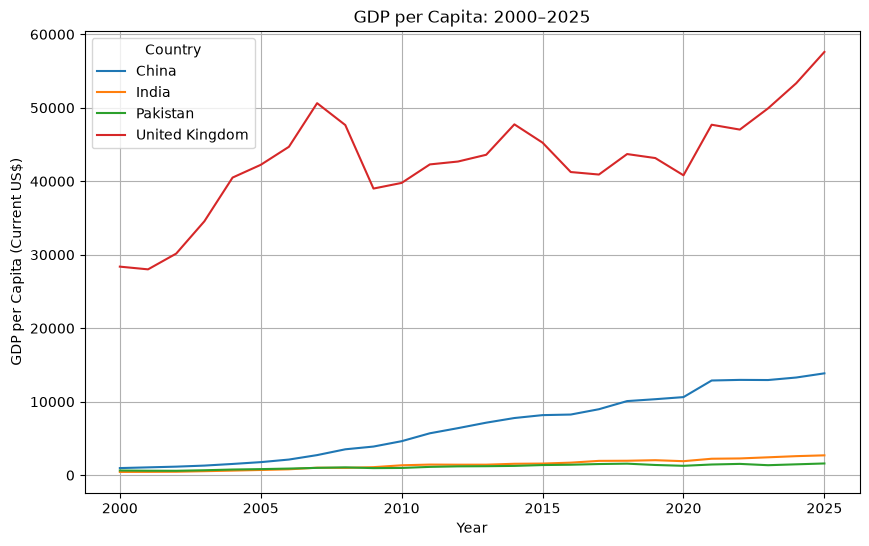

In [52]:
import matplotlib.pyplot as plt

pivot.plot(figsize=(10, 6))

plt.title("GDP per Capita: 2000–2025")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (Current US$)")
plt.grid(True)

plt.show()

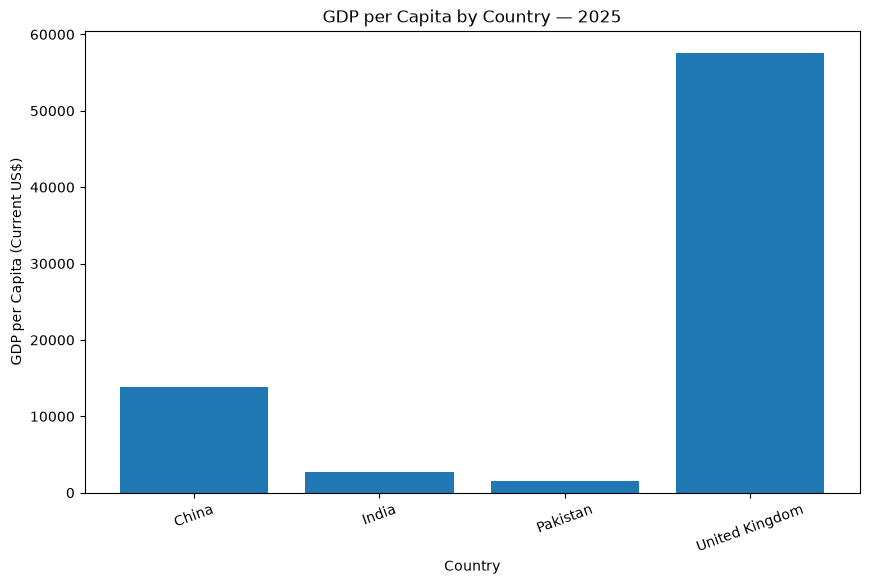

In [53]:
latest = df[df['Year'] == 2025]

plt.figure(figsize=(10, 6))

plt.bar(latest['Country'], latest['GDP_per_capita'])

plt.title("GDP per Capita by Country — 2025")
plt.xlabel("Country")
plt.ylabel("GDP per Capita (Current US$)")
plt.xticks(rotation=20)

plt.show()

In [54]:
df.to_csv("country_income_clean.csv", index=False)

In [55]:
import os
print(os.path.exists("country_income_clean.csv"))

True


In [56]:
df.to_excel("country_income_clean.xlsx", index=False)

In [57]:
import os

print(os.listdir())

['.venv', 'countries_income_analysis.ipynb', 'country_income_clean.csv', 'country_income_clean.xlsx', 'data', 'requirements.txt']


In [58]:
summary = growth.merge(
    avg_gdp.rename('Average_GDP_per_capita'),
    on='Country'
)

summary = summary.round(2)

print(summary)

          Country  GDP_per_capita_2000  GDP_per_capita_2025    Change  \
0           China               969.20             13861.97  12892.77   
1           India               442.75              2702.48   2259.73   
2        Pakistan               642.34              1595.91    953.57   
3  United Kingdom             28383.88             57601.96  29218.09   

   Growth_Percentage  Average_GDP_per_capita  
0            1330.25                 6699.84  
1             510.38                 1452.54  
2             148.45                 1148.51  
3             102.94                42794.89  


In [59]:
with pd.ExcelWriter("country_income_analysis.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    summary.to_excel(writer, sheet_name="Analysis Summary", index=False)
    pivot.to_excel(writer, sheet_name="Yearly Comparison")

In [60]:
import os

print(os.path.exists("country_income_analysis.xlsx"))

True
